In [1]:
import sys
import os

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)
sys.path.insert(0, "/Odyssey/private/o23gauvr/code/FASCINATION")
#from FASCINATION.src.autoencoder_datamodule_good_split import AEDatamodule

import subprocess
import numpy as np
import xarray as xr
from pathlib import Path
import pickle
import torch
import torch.nn as nn
from MLIC.MLIC.models import MLICPlusPlus
from MLIC.MLIC.utils.utils import Config
from pathlib import Path
import shutil
from IPython.display import Image, display
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA



from FASCINATION.src.utils import unorm_ssp_arr_3D, get_cfg_from_ckpt_path, load_model



# Functions

In [2]:


def parse_experiment_config(ckpt_path):
    """
    Parse experiment_config.log file to extract N and M values.
    
    Args:
        ckpt_path (str): PosixPath to checkpoint 
        
    Returns:
        tuple: (N, M) values or (None, None) if parsing fails
    """

    config_file = list((ckpt_path.parent.parent).rglob("train_*.log")) 
    if not config_file:
        print(f"Warning: train logs not found in {ckpt_path}")
        return None, None
    
    config_file = config_file[0]  # Get the first match if multiple found

    try:
        with open(config_file, 'r') as f:
            content = f.read()
        
        # Extract N and M values from MODEL CONFIGURATION section
        N, M = None, None
        
        lines = content.split('\n')

        cfg = eval((lines[1].strip().split("INFO: ")[-1]).replace("<class 'torch.nn.modules.activation.","nn.").replace("'>",""))


        return cfg
        
            
    except Exception as e:
        print(f"Error parsing config file in {ckpt_path}: {e}")
        return None




In [3]:
def lon_distance_meters(lat, lon1, lon2):
    """
    Compute distance in meters between two longitudes at a given latitude.
    
    Args:
        lat: latitude in degrees
        lon1, lon2: longitudes in degrees
        
    Returns:
        Distance in meters
    """
    R = 6_371_000  # Earth radius in meters
    lat_rad = np.radians(lat)
    dlon_rad = np.radians(lon2 - lon1)
    
    distance = R * np.cos(lat_rad) * np.abs(dlon_rad)
    return distance

In [4]:


def create_ramgeo_config(title, ssp_profile, depth_array, 
                         r_update=5000, 
                         freq=500, source_depth=3.0, receiver_depth=300.0,
                         rmax=10000.0, dr=.749, ndr=1,
                         zmax=2000.0, dz=.149, ndz=1, zmplt=1000.0,
                         c0=1500.0, n_pade=8, ns=1, rs=0.0):
    """Create RAMGEO config from SSP profile."""
    


    r = 0.0

    config = f"""{title}
{freq} {source_depth} {receiver_depth}	Frequency (Hz), source depth (m), receiver depth(s) (m)   
{rmax}	{dr} {ndr}	Max range (m), range step dr (m) range decimation
{zmax}	{dz} {ndz} {zmplt}	Max depth (m), depth step dz (m), depth decimation, depth for plotting (m)
{c0}	{n_pade} {ns} {rs}	Reference sound speed (m/s) Number of Padé terms, number of stability constraints in Pade approximation, Range of starter (0 means standard point source starter)
0.0	{2*zmax}	bathymetry data r,z in [m, m]
{rmax}	{2*zmax}
-1	-1
"""
#     config = f"""{title}
# {freq} {source_depth} {receiver_depth}    freq zs zr
# {rmax} {dr} {ndr}      rmax dr ndr
# {zmax} {dz} {ndz} {zmplt}     zmax dz ndz zmplt
# {c0} {n_pade} {ns}     c0 np ns rs 
# 0.0 {2*zmax}    rb zb 
# {rmax} {2*zmax} rb zb 
# -1 -1
# """
    # Add SSP profile
    assert ssp_profile.shape[0] == len(depth_array), "SSP profile and depth array must have the same length."

    if len(ssp_profile.shape) == 1:
        ssp_profile = np.expand_dims(ssp_profile,axis=-1)

    for j in range(ssp_profile.shape[1]):
        if j>0:
            config += f"{r}	!update profile\n"


        for i, (z, c) in enumerate(zip(depth_array, ssp_profile[:,j])):
            if i == 0:
                config += f"{z:.2f}	{c:.2f}	SSP profile (depth, sound speed)\n"
            else:
                config += f"{z:.2f}	{c:.2f}\n"

        config += """-1	-1 
0.0	1800.0	compressive sound speed profile in substrate {z,cbp} [m, m/s]
100.0   1800.0
-1	-1
0.0	1.7	density profile in substrate {z,rho} [m, g/cm³]
100.0   1.7
-1	-1
0.0	0.4	compressive attenuation profile  {z,attnp} [m, dB/lambda]
10.0    0.4
100.0	10.0    buffer layer with totam attenuation
-1	-1
"""

        r+= r_update
        if r>rmax:
            break



    output_path = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/{title.replace(' ', '_')}.in"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    with open(output_path, 'w') as f:
        f.write(config)
    
    return output_path



#config_path = create_ramgeo_config("test_rad", ssp_ae_rad, depth_array,r_update=3000)


In [5]:

def process_model_in_batches(model, data_tensor, batch_size=4, dim=0, device='cuda'):
    """
    Process large tensors through model in batches to avoid OOM.
    
    Args:
        model: PyTorch model
        data_tensor: Input tensor
        batch_size: Number of samples per batch
        dim: Dimension along which to batch (0=time, 2=lat, 3=lon)
        device: Device to use
        
    Returns:
        numpy array of model outputs concatenated
    """
    results = []
    n_samples = data_tensor.shape[dim]
    
    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Processing batches"):
            end_idx = min(i + batch_size, n_samples)
            
            # Create slice for the batch
            slices = [slice(None)] * len(data_tensor.shape)
            slices[dim] = slice(i, end_idx)
            
            batch_data = data_tensor[tuple(slices)]
            batch_output = model(batch_data).detach().cpu().numpy()
            results.append(batch_output)
    
    # Concatenate along the same dimension
    output = np.concatenate(results, axis=dim)
    return output


In [6]:
def apply_pooling_upsample_to_pca(pca_ae: np.ndarray, ssp_truth_shape: tuple, n_layer_pooling: int, pooling_mode: str = "mean") -> np.ndarray:
    """
    Apply spatial pooling and upsampling to PCA-transformed data using numpy/scipy, then inverse transform.
    Works entirely with numpy arrays using skimage.measure.block_reduce and scipy.interpolate.RectBivariateSpline.
    
    Args:
        pca_ae: flattened PCA-transformed array with shape (batch*lat*lon, n_components)
        ssp_truth_shape: tuple of original spatial shape (batch, depth, lat, lon)
        n_layer_pooling: number of pooling layers to apply (e.g., 3)
        pca: fitted PCA object with inverse_transform method
        pooling_mode: "mean" for average pooling or "max" for max pooling
        
    Returns:
        reconstructed: data in shape (batch, depth, lat, lon) after pooling/upsampling and inverse transform
    """
    from skimage.measure import block_reduce
    from scipy.interpolate import RectBivariateSpline
    
    batch, depth, lat, lon = ssp_truth_shape
    n_components = pca_ae.shape[1]
    
    # Reshape from (batch*lat*lon, n_components) to (batch, lat, lon, n_components)
    pca_ae_reshaped = pca_ae.reshape(batch, lat, lon, n_components)
    
    # Transpose to (batch, n_components, lat, lon) for spatial pooling
    pca_ae_spatial = pca_ae_reshaped.transpose(0, 3, 1, 2)  # (batch, n_components, lat, lon)
    
    # Apply pooling and upsampling for each batch and component
    pooled_upsampled_list = []
    
    for b in range(batch):
        component_list = []
        for c in range(n_components):
            data_2d = pca_ae_spatial[b, c, :, :]  # (lat, lon)
            
            # Apply pooling layers
            pooled_data = data_2d.copy()
            for _ in range(n_layer_pooling):
                block_size = 2
                if pooling_mode == "mean":
                    pooled_data = block_reduce(pooled_data, block_size=(block_size, block_size), func=np.mean)
                else:  # max
                    pooled_data = block_reduce(pooled_data, block_size=(block_size, block_size), func=np.max)
            
            # Upsample back to original size using RectBivariateSpline
            pooled_h, pooled_w = pooled_data.shape

            
            # Create coordinate arrays for the pooled data
            y_old = np.arange(pooled_h)
            x_old = np.arange(pooled_w)
            
            # Create RectBivariateSpline interpolator (cubic by default, kx=ky=3)
            spl = RectBivariateSpline(y_old, x_old, pooled_data, kx=min(3, pooled_h-1), ky=min(3, pooled_w-1))
            
            # Create new coordinate arrays for upsampled data
            y_new = np.linspace(0, pooled_h - 1, lat)
            x_new = np.linspace(0, pooled_w - 1, lon)
            
            # Interpolate to original size
            upsampled_data = spl(y_new, x_new, grid=True)
            
            component_list.append(upsampled_data)
        
        # Stack components and convert to (n_components, lat, lon)
        pooled_upsampled_list.append(np.array(component_list))
    
    # Concatenate batches: (batch, n_components, lat, lon)
    pooled_upsampled_np = np.array(pooled_upsampled_list)
    
    # Reshape to flattened form (batch*lat*lon, n_components) for inverse transform
    pooled_upsampled_flat = pooled_upsampled_np.transpose(0, 2, 3, 1).reshape(-1, n_components)
    
    return pooled_upsampled_flat


# Load data

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [8]:
data_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_good_split.pkl"
with open(data_path, 'rb') as f:
    dm = pickle.load(f)

In [9]:
ssp_da = dm.test_ds.input
depth_array = ssp_da.z.values
test_norm = ssp_da.attrs['norm_stats']
season_idx = dm.test_ds.input.season_idx
sst_test_norm  = dm.test_ds.input.attrs['sst'].data


In [10]:
# Select profile near source location
ssp_truth = ssp_da.values
ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)



## load mlic

In [11]:
model = "MLIC"
cr = "1000"
ckpt_file = Path("/Odyssey/private/o23gauvr/code/MLIC/experiments/article_cr/fixed_weight_loss_64_96_1.0_CR_1000.0_enatl_natl__mean_std/20260407_004827/checkpoints/best_checkpoint_rmse.pth.tar") 
#list(Path("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/eusipco/MLIC/SSP").glob(f"fixed_weight_loss_64_96_1.0_CR_{cr}.0*/**/*_rmse.pth.tar"))[0]
cfg = parse_experiment_config(ckpt_file)
N = cfg.get('N', 192)
M = cfg.get('M', 320)
ssp_config = Config({
    'N': N, 'M': M, 'slice_num': cfg.get('slice_num', 10),
    'context_window': cfg.get('context_window', 5), 'act': cfg.get('act', nn.GELU),
    'in_channels': cfg.get('in_channels', 157), 'out_channels': cfg.get('in_channels', 157), 
    "add_seasons": cfg.get("add_seasons", {"use": False, "mode": None}),
    "add_sst": cfg.get("add_sst", False)
})

# try:
#     cr = str(ckpt_file).split("CR_")[-1].split("_")[0]
# except:
#     cr = ""



        

In [12]:
try:
    net = MLICPlusPlus(config=ssp_config).eval().to(device)
    ck = torch.load(ckpt_file, map_location=device)
    if "one_hot_old" in str(ckpt_file) or str(ckpt_file) == "/Odyssey/private/o23gauvr/code/MLIC/experiments/full_loss_batch_4_add_season_hot_one_64_96_0.0018_min_max/20251001_001608/checkpoints/checkpoint_best_loss.pth.tar":
        del ck['state_dict']["season_embed.weight"]
    net.load_state_dict(ck['state_dict'])


    test_norm = ck.get('train_norm_stats', None)

    
    if test_norm['method'] == "min_max":
        x_min = test_norm["params"]["x_min"].astype(ssp_truth.dtype)
        x_max = test_norm["params"]["x_max"].astype(ssp_truth.dtype)    
        ssp_truth = (ssp_truth - x_min) / (x_max - x_min)
    elif test_norm['method'] == "mean_std":
        mean = test_norm['params']["mean"].astype(ssp_truth.dtype)
        std = test_norm['params']["std"].astype(ssp_truth.dtype)
        ssp_truth = (ssp_truth - mean) / std
    elif test_norm['method'] == "mean_std_along_depth":
        mean = test_norm['params']["mean_along_depth"].astype(ssp_truth.dtype)
        std = test_norm['params']["std_along_depth"].astype(ssp_truth.dtype)
        ssp_truth = (ssp_truth - mean) / std

except Exception as e:
    print(f"Error loading model or normalizing data: {e}")



/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_338470/353602132.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode 

In [13]:

ssp_truth_tens = torch.tensor(ssp_truth).to(device=device, dtype=getattr(torch,dm.dtype_str))
with torch.no_grad():
    rv_batch = net(ssp_truth_tens, season_idx, sst_test_norm)

ssp_ae = rv_batch['x_hat'].detach().cpu().numpy()

ssp_ae = unorm_ssp_arr_3D(ssp_ae, test_norm)
ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)


## load CAE

In [26]:
model = "CAE"
cr = "1000"

ckpt_file = Path("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/eusipco/AE/pred_1_grad_0_max_pos_0_max_value_0_fft_0_weighted_1_inflection_pos_0_inflection_value_0/dense_True/pooling_Avg_on_dim_dense/channels_[5000, 3000, 1000, 10]/upsample_mode_trilinear/linear_layer_False/cr_100000/1_conv_per_layer/padding_cubic/interp_size_5/final_upsample_upsample/act_fn_None/use_final_act_fn_False/lr_0.001/normalization_mean_std_along_depth/manage_nan_supress_with_max_depth/2026-02-13_12-43/checkpoints/best_checkpoint_loss.pth.tar")


cfg = get_cfg_from_ckpt_path(str(ckpt_file), pprint=False)
ck = torch.load(ckpt_file, map_location=device)
test_norm = ck.get('norm_stats', None)
if test_norm['method'] == "min_max":
    x_min = test_norm["params"]["x_min"].astype(ssp_truth.dtype)
    x_max = test_norm["params"]["x_max"].astype(ssp_truth.dtype)    
    ssp_truth_tens = (ssp_truth - x_min) / (x_max - x_min)
elif test_norm['method'] == "mean_std":
    mean = test_norm['params']["mean"].astype(ssp_truth.dtype)
    std = test_norm['params']["std"].astype(ssp_truth.dtype)
    ssp_truth_tens = (ssp_truth - mean) / std
elif test_norm['method'] == "mean_std_along_depth":
    mean = test_norm['params']["mean_along_depth"].astype(ssp_truth.dtype)
    std = test_norm['params']["std_along_depth"].astype(ssp_truth.dtype)
    ssp_truth_tens = (ssp_truth - mean) / std


ssp_truth_tens = torch.tensor(ssp_truth_tens).to(device=device, dtype=getattr(torch,dm.dtype_str))
lit_model = load_model(str(ckpt_file), dm, ssp_truth_tens, verbose=False)

# Process in batches to avoid OOM
batch_size = 4  # Adjust based on GPU memory
print(f"Processing {ssp_truth_tens.shape[0]} samples in batches of {batch_size}...")
ssp_ae = process_model_in_batches(lit_model, ssp_truth_tens, batch_size=batch_size, dim=0, device=device)
print(f"✓ Processing complete. Output shape: {ssp_ae.shape}")

ssp_ae = unorm_ssp_arr_3D(ssp_ae, test_norm)
ssp_ae_da = ssp_da.copy(data=ssp_ae)




/tmp/ipykernel_2846205/2655186293.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(ckpt_file, map_location=device)
/Odyssey/private/o23gauvr/miniforge3/en

Processing 97 samples in batches of 4...


Processing batches: 100%|██████████| 25/25 [00:03<00:00,  8.18it/s]


✓ Processing complete. Output shape: (97, 157, 192, 256)


## Load PCA

In [43]:
model = "PCA"
n_components = 10
n_layer_pooling = 3
#cr = 4**n_layer_pooling*ssp_truth.shape[1]/n_components 
pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42)
pca.fit(ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1]))
pca_ae = pca.transform(ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1]))
ssp_ae = apply_pooling_upsample_to_pca(
    pca_ae,
    ssp_truth_shape=ssp_truth.shape,
    n_layer_pooling=n_layer_pooling,
)
ssp_ae = pca.inverse_transform(ssp_ae).reshape(ssp_truth.shape[0], ssp_truth.shape[2], ssp_truth.shape[3], ssp_truth.shape[1]).transpose(0,3,1,2)
ssp_ae_da = ssp_da.copy(data=ssp_ae)

# Run models random profiles

In [12]:
t,lat,lon = 10,10,10

In [13]:
ssp_ae_profile = ssp_ae[t,:, lat, lon]  # Select profile at lat=100, lon=100

ssp_truth_profile = ssp_truth[t,:, lat, lon]

np.float64(0.04686274509803655)

In [122]:
dr_min =lon_distance_meters(45.0,0, np.diff(ssp_da.lon.values).mean())
dr_min

np.float64(3684.6623750339195)

## Truth

In [149]:


prof = ssp_truth_profile
title = f"RAMGEO_SSP_TRUTH"

config_path_truth = create_ramgeo_config(title, prof, depth_array, 
                         r_update=0, 
                         freq=1000, source_depth=5.0, receiver_depth=300.0,
                         rmax=10000.0, dr=.749, ndr=1,
                         zmax=2000.0, dz=.149, ndz=1, zmplt=1000.0,
                         c0=1500.0, n_pade=8, ns=1, rs=0.0)

xp_truth = config_path_truth.split("/")[-1].split(".")[0]

In [150]:
# Run RAMGEO simulation and post-processing for current experiment
truth_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", truth_dir)

'/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH'

In [151]:
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_truth}',
    f'--output-dir={truth_dir}'
])

Frequency:  1000.00 Hz
Wavelength:     1.50 m
Depth step dz:    0.149 m [fixed - original compatibility]
Range step dr:    0.749 m [fixed - original compatibility]
  dz/wavelength =    0.099 (should be < 0.1 for accuracy)
  dr/wavelength =    0.499 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 2014

CPU time (RAM run):     13.793 s


CompletedProcess(args=['/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo', '--input=/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/RAMGEO_SSP_TRUTH.in', '--output-dir=/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH'], returncode=0)

In [142]:
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', truth_dir
])

RAM Acoustic Model - Result Plotter

Reading input parameters...
  Parameters read from output file headers
  Frequency: 1000.0 Hz
  Source depth: 5.0 m
  Receiver depths: 300.0 m (1 receivers)
  Max range: 10000.0 m
  Range step (dr): 0.750000 m
  Range decimation (ndr): 1
  Depth step (dz): 0.150000 m
  Depth decimation (ndz): 1
  Plot depth limit (zmplt): 1000.0 m

Reading output files...
  TL line: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH/tl.line
  TL grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH/tl.grid
  P grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH/p.grid

Determining grid size for automatic subsampling...
  Grid dimensions: 6666 depth × 13334 range points
  Auto-calculated range subsampling: 1:4 (13334 → 3333 points)
  Auto-calculated depth subsampling: 1:2 (6666 → 3333 points)

Final subsampling: Range 1:4, Depth 1:2
(Range subsampling occurs while reading files; depth sub

CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py', '--data-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH'], returncode=0)

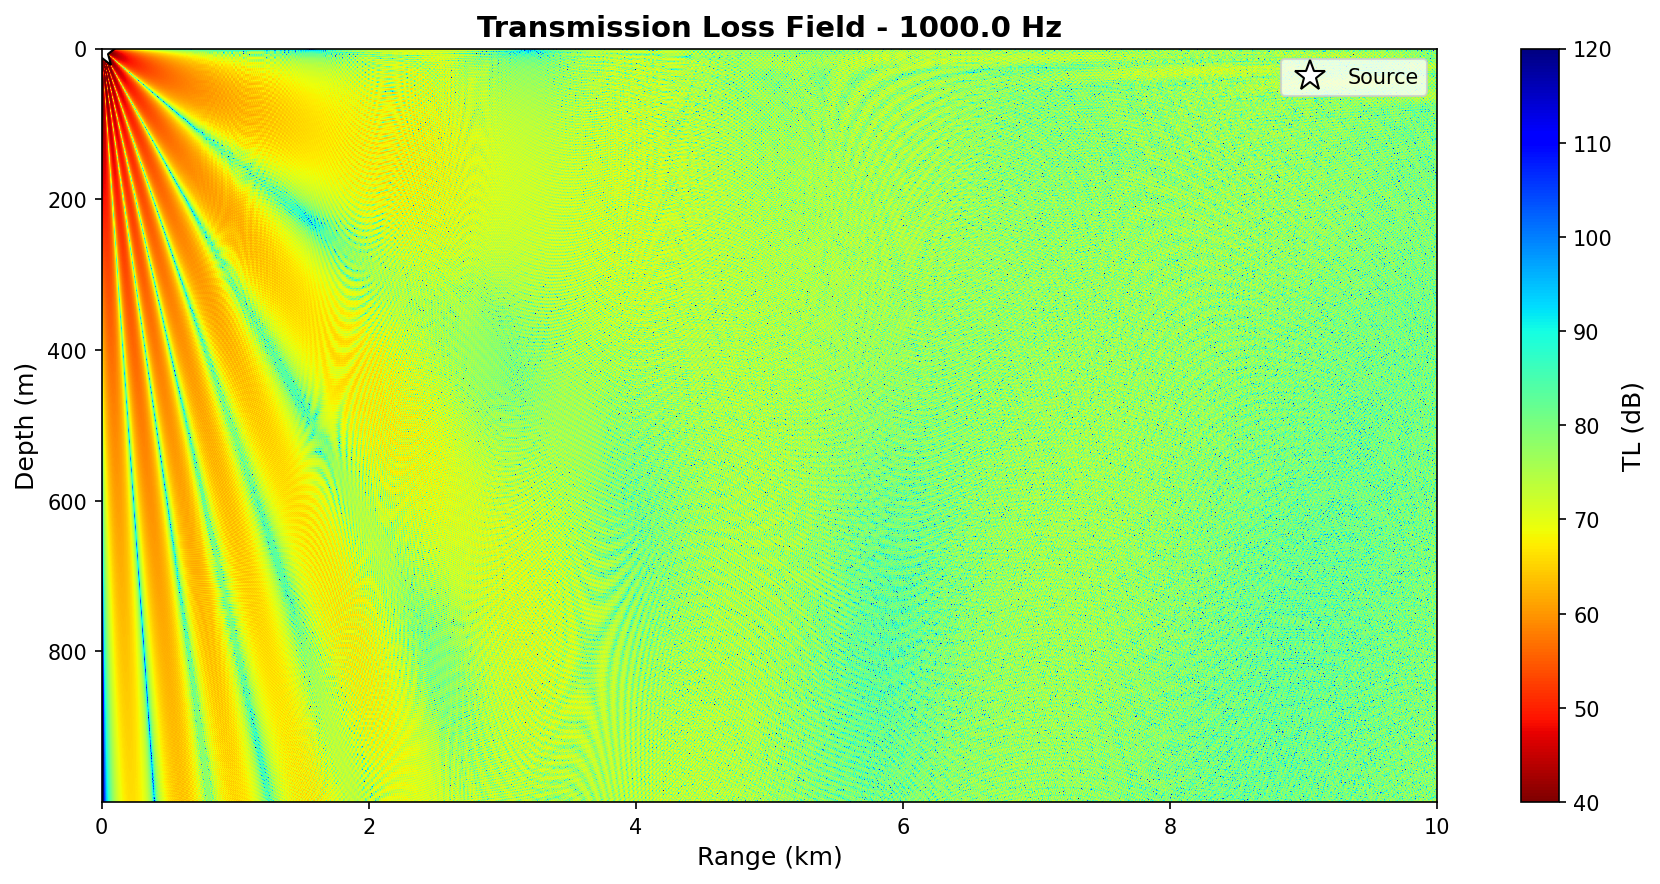

In [143]:


img_path = "/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH/figures/tl_field.png"
display(Image(filename=img_path))

## AE

In [145]:

prof = ssp_ae_profile
title = f"RAMGEO_REC_CR_{cr}"


config_path_ae = create_ramgeo_config(title, prof, depth_array)
xp_ae = config_path_ae.split("/")[-1].split(".")[0]

print(f"Config for RAMGEO AE created at: {config_path_ae}")

Config for RAMGEO AE created at: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/RAMGEO_REC_CR_10000.0.in


In [146]:
# Run RAMGEO simulation and post-processing for current experiment
ae_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", ae_dir)

'/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000'

In [147]:
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_ae}',
    f'--output-dir={ae_dir}'
])

Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    0.149 m [fixed - original compatibility]
Range step dr:    0.749 m [fixed - original compatibility]
  dz/wavelength =    0.050 (should be < 0.1 for accuracy)
  dr/wavelength =    0.250 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 2014

CPU time (RAM run):     13.795 s


CompletedProcess(args=['/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo', '--input=/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/RAMGEO_REC_CR_10000.0.in', '--output-dir=/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000'], returncode=0)

In [148]:
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', ae_dir
])

RAM Acoustic Model - Result Plotter

Reading input parameters...
  Parameters read from output file headers
  Frequency: 500.0 Hz
  Source depth: 3.0 m
  Receiver depths: 300.0 m (1 receivers)
  Max range: 10000.0 m
  Range step (dr): 0.749000 m
  Range decimation (ndr): 1
  Depth step (dz): 0.149000 m
  Depth decimation (ndz): 1
  Plot depth limit (zmplt): 1000.0 m

Reading output files...
  TL line: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000/tl.line
  TL grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000/tl.grid
  P grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000/p.grid

Determining grid size for automatic subsampling...
  Grid dimensions: 6710 depth × 13351 range points
  Auto-calculated range subsampling: 1:4 (13351 → 3337 points)
  Auto-calculated depth subsampling: 1:2 (6710 → 3355 points)

Final subsampling: Range 1:4, Depth 1:2
(Range subsampling occurs while reading files; d

CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py', '--data-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000'], returncode=0)

## Differences

In [22]:
# Compute differences with truth
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py',
    '--rec-dir', ae_dir,
    '--truth-dir', truth_dir,
    '--output-dir', "/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/"
])

RAMGEO Difference Analysis Tool

REC directory:    /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000
TRUTH directory:  /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH
Output directory: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000

Reading parameters from: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/config/RAMGEO_SSP_TRUTH_DECILE_0_t_49_lat_59_lon_151.in
  Frequency: 500.0 Hz
  Source depth: 3.0 m

Computing Differences

Processing TL line files...
  Receiver 1: Mean diff = 4.0057 dB, Max diff = 27.5427 dB
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/tl_diff.line

Processing TL grid files...
  Grid shape: (999, 1000)
  Mean diff: nan dB
  Max diff: nan dB
  Median diff: nan dB
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/tl_diff.grid

Processing pressure grid files...
  Grid shape: (999, 1000)
  Complex di

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:350: RuntimeWarning: invalid value encountered in subtract
  tl_diff_grid = np.abs(rec_tl_grid - truth_tl_grid)


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/figures/tl_diff_vs_range.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/figures/tl_diff_field.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/figures/pressure_diff_field.png


/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000/figures/difference_summary.png

Analysis Complete!

Output files saved to: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000

Generated files:
  - tl_diff.line
  - tl_diff.grid
  - p_diff.grid
  - diff_statistics.txt
  - figures/tl_diff_vs_range.png
  - figures/tl_diff_field.png
  - figures/pressure_diff_field.png
  - figures/difference_summary.png


CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py', '--rec-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000', '--truth-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH', '--output-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/'], returncode=0)

# Profiles per decile

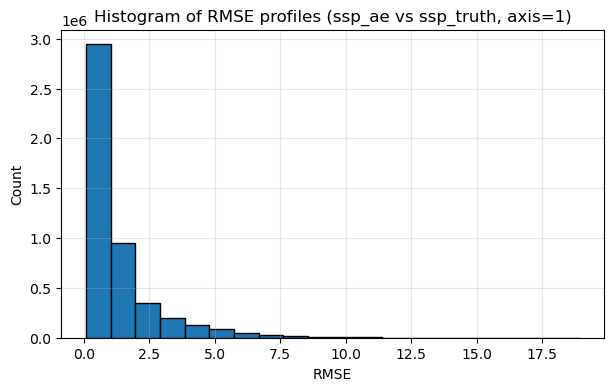

In [27]:
import matplotlib.pyplot as plt

# RMSE along 2nd dimension (axis=1, typically depth)
rmse_depth = np.sqrt(np.nanmean((ssp_ae - ssp_truth) ** 2, axis=1))

# Histogram with 20 bins (flatten all remaining dimensions)
plt.figure(figsize=(7, 4))
plt.hist(rmse_depth.ravel(), bins=20, edgecolor="black")
plt.xlabel("RMSE")
plt.ylabel("Count")
plt.title("Histogram of RMSE profiles (ssp_ae vs ssp_truth, axis=1)")
plt.grid(alpha=0.3)
plt.show()

In [28]:
ssp_truth_da = ssp_da.copy(data=ssp_truth)
ssp_ae_da = ssp_da.copy(data=ssp_ae)

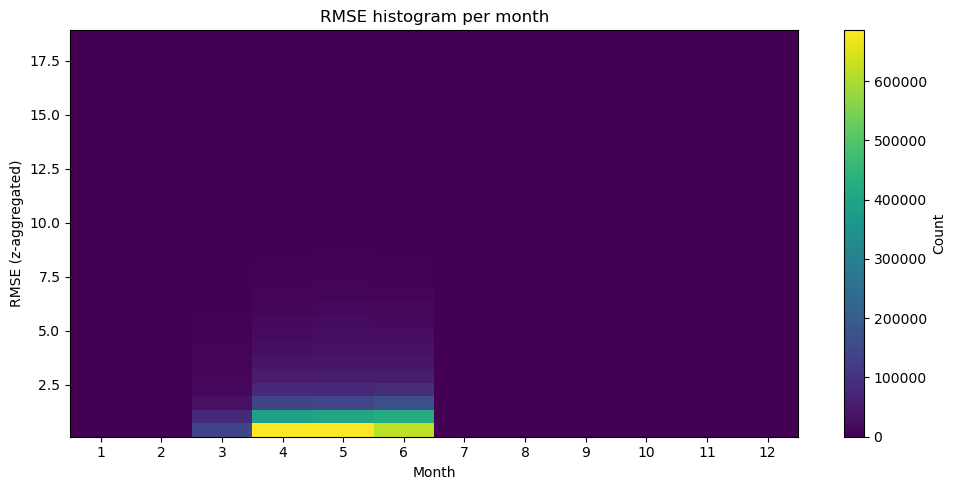

In [29]:
# RMSE along z (keeps dims: time, lat, lon)
rmse_z = np.sqrt(((ssp_ae_da - ssp_truth_da) ** 2).mean(dim="z", skipna=True))

month_idx = rmse_z["time"].dt.month.values
rmse_vals = rmse_z.values  # shape: (time, lat, lon)

# RMSE bins
valid = np.isfinite(rmse_vals)
rmse_min = np.nanmin(rmse_vals[valid])
rmse_max = np.nanmax(rmse_vals[valid])
bins = np.linspace(rmse_min, rmse_max, 31)

# Histogram count per month
hist_per_month = np.zeros((len(bins) - 1, 12), dtype=int)
for m in range(1, 13):
    mask_t = month_idx == m
    vals_m = rmse_vals[mask_t, ...].ravel()
    vals_m = vals_m[np.isfinite(vals_m)]
    hist_per_month[:, m - 1], _ = np.histogram(vals_m, bins=bins)

# Colormesh: months on x, RMSE on y, count as color
month_edges = np.arange(0.5, 13.5, 1.0)  # 12 month bins -> 13 edges

plt.figure(figsize=(10, 5))
pcm = plt.pcolormesh(month_edges, bins, hist_per_month, shading="auto")
plt.xlim(0.5, 12.5)
plt.xticks(np.arange(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (z-aggregated)")
plt.title("RMSE histogram per month")
cbar = plt.colorbar(pcm)
cbar.set_label("Count")
plt.tight_layout()
plt.show()

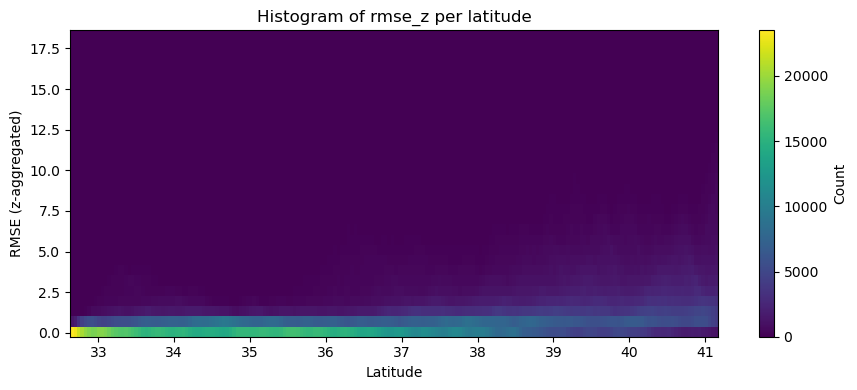

In [30]:
# Histogram of rmse_z per latitude coordinate (time/lon collapsed)
rmse_vals = rmse_z.values  # expected shape: (time, lat, lon)
lat_vals = rmse_z["lat"].values

# RMSE bins
rmse_min = np.nanmin(rmse_vals)
rmse_max = np.nanmax(rmse_vals)
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per latitude
hist_per_lat = np.zeros((len(lat_vals), len(bins) - 1), dtype=int)
for i in range(len(lat_vals)):
    vals_i = rmse_vals[:, i, :].ravel()
    vals_i = vals_i[np.isfinite(vals_i)]
    hist_per_lat[i], _ = np.histogram(vals_i, bins=bins)

# Plot as 2D histogram heatmap
plt.figure(figsize=(9, 4))
plt.pcolormesh(lat_vals, bins[:-1], hist_per_lat.T, shading="auto")
plt.xlabel("Latitude")
plt.ylabel("RMSE (z-aggregated)")
plt.title("Histogram of rmse_z per latitude")
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

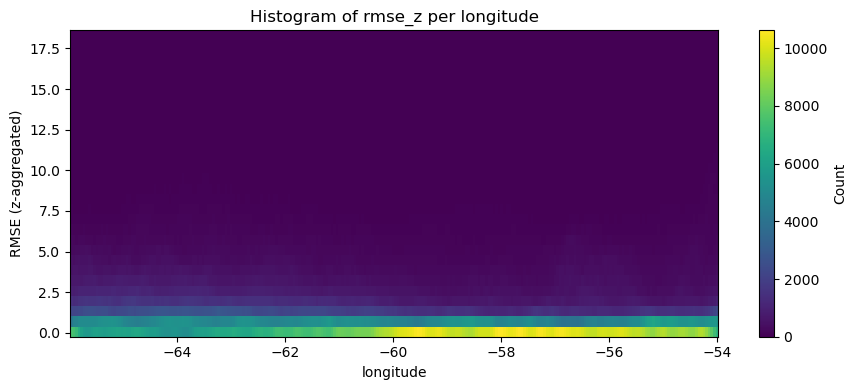

In [31]:
# Histogram of rmse_z per longitude coordinate (time/lon collapsed)
rmse_vals = rmse_z.values  # expected shape: (time, lon, lon)
lon_vals = rmse_z["lon"].values

# RMSE bins
rmse_min = np.nanmin(rmse_vals)
rmse_max = np.nanmax(rmse_vals)
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per longitude
hist_per_lon = np.zeros((len(lon_vals), len(bins) - 1), dtype=int)
for i in range(len(lon_vals)):
    vals_i = rmse_vals[:, :, i].ravel()
    vals_i = vals_i[np.isfinite(vals_i)]
    hist_per_lon[i], _ = np.histogram(vals_i, bins=bins)

# Plot as 2D histogram heatmap
plt.figure(figsize=(9, 4))
plt.pcolormesh(lon_vals, bins[:-1], hist_per_lon.T, shading="auto")
plt.xlabel("longitude")
plt.ylabel("RMSE (z-aggregated)")
plt.title("Histogram of rmse_z per longitude")
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

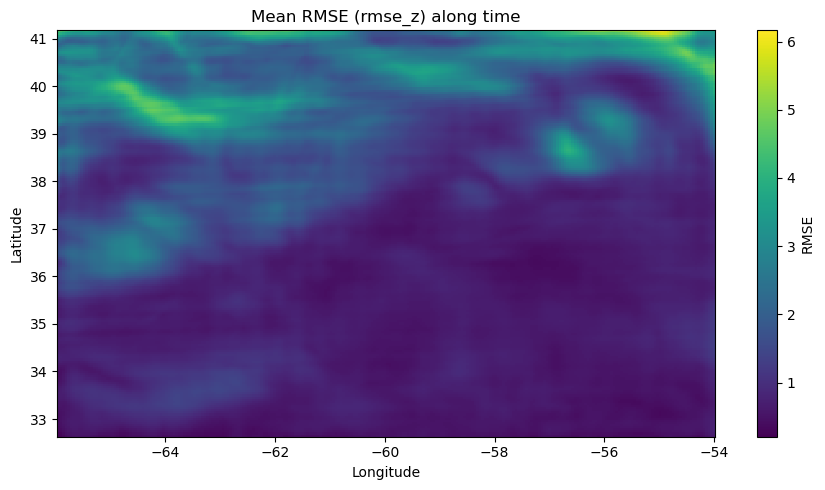

In [32]:
rmse_z_mean_time = rmse_z.mean(dim="time", skipna=True)

lon_vals = rmse_z_mean_time["lon"].values
lat_vals = rmse_z_mean_time["lat"].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)

plt.figure(figsize=(9, 5))
pcm = plt.pcolormesh(lon_grid, lat_grid, rmse_z_mean_time.values, shading="auto")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean RMSE (rmse_z) along time")
cbar = plt.colorbar(pcm)
cbar.set_label("RMSE")
plt.tight_layout()
plt.show()

In [33]:
import numpy as np

# Flatten rmse_z and get valid (non-NaN) values with indices
rmse_flat = rmse_z.values.ravel()
valid_mask = np.isfinite(rmse_flat)
valid_values = rmse_flat[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Compute 10 decile thresholds: 0%, 11.1%, 22.2%, ..., 100%
percentiles = np.linspace(0, 100, 11)
thresholds = np.percentile(valid_values, percentiles)

# For each threshold, find the closest actual data point
selected_flat_indices = []
for thresh in thresholds:
    idx_in_valid = np.argmin(np.abs(valid_values - thresh))
    selected_flat_indices.append(valid_indices[idx_in_valid])

# Convert flat indices back to multi-dimensional coordinates
shape = rmse_z.shape
dim_names = rmse_z.dims
selected_points = []

for i, flat_idx in enumerate(selected_flat_indices):
    multi_idx = np.unravel_index(flat_idx, shape)
    point = {dim: int(idx) for dim, idx in zip(dim_names, multi_idx)}  # integer indices
    point['rmse_value'] = rmse_flat[flat_idx]
    point['percentile'] = percentiles[i]
    selected_points.append(point)

# Display results
import pandas as pd
df_deciles = pd.DataFrame(selected_points)
print(df_deciles)

    time  lat  lon  rmse_value  percentile
0     26    1   71    0.083394         0.0
1     59   30    6    0.342137        10.0
2     15   29    9    0.439955        20.0
3     52   46    9    0.538494        30.0
4     74   40  160    0.651245        40.0
5     45    7   13    0.792471        50.0
6     13   98   18    0.984375        60.0
7     49  182   23    1.276557        70.0
8     66  141  127    1.829693        80.0
9     89  139    9    3.117323        90.0
10    30  191  229   18.921165       100.0


In [32]:
t,lat,lon = df_deciles['time'][decile], df_deciles['lat'][decile], df_deciles['lon'][decile]
ssp_ae_profile = ssp_ae[t,:, lat, lon]  # Select profile at lat=100, lon=100

ssp_truth_profile = ssp_truth[t,:, lat, lon]
## Truth


prof = ssp_truth_profile
title = f"RAMGEO_SSP_TRUTH_DECILE_{decile}_t_{t}_lat_{lat}_lon_{lon}"


config_path_truth = create_ramgeo_config(title, prof, depth_array)
xp_truth = config_path_truth.split("/")[-1].split(".in")[0].replace(".0", "")
# Run RAMGEO simulation and post-processing for current experiment
truth_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_truth}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", truth_dir)
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_truth}',
    f'--output-dir={truth_dir}'
])
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', truth_dir
])
## AE

prof = ssp_ae_profile
title = f"RAMGEO_REC_CR_{cr}_DECILE_{decile}_t_{t}_lat_{lat}_lon_{lon}"


config_path_ae = create_ramgeo_config(title, prof, depth_array)
xp_ae = config_path_ae.split("/")[-1].split(".in")[0].replace(".0", "")

print(f"Config for RAMGEO AE created at: {config_path_ae}")
# Run RAMGEO simulation and post-processing for current experiment
ae_dir = f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"

# Copy template results directory

if os.path.exists(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}"):
    shutil.rmtree(f"/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/{xp_ae}")
shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", ae_dir)
# Run RAMGEO
subprocess.run([
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
    f'--input={config_path_ae}',
    f'--output-dir={ae_dir}'
])
# Plot results
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
    '--data-dir', ae_dir
])
## Differences
# Compute differences with truth
subprocess.run([
    'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py',
    '--rec-dir', ae_dir,
    '--truth-dir', truth_dir,
    '--output-dir', "/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/"
])

Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    1.000 m [fixed - original compatibility]
Range step dr:   10.000 m [fixed - original compatibility]
  dz/wavelength =    0.333 (should be < 0.1 for accuracy)
  dr/wavelength =    3.333 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 301

CPU time (RAM run):      0.136 s
RAM Acoustic Model - Result Plotter

Reading input parameters...
  Parameters read from output file headers
  Frequency: 500.0 Hz
  Source depth: 3.0 m
  Receiver depths: 300.0 m (1 receivers)
  Max range: 10000.0 m
  Range step (dr): 10.000000 m
  Range decimation (ndr): 1
  Depth step (dz): 1.000000 m
  Depth decimation (ndz): 1
  Plot depth limit (zmplt): 1000.0 m

Reading output files...
  TL line: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH_DECILE_0_t_9_lat_31_lon_91/tl.line
  TL grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH_DECILE_0

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:350: RuntimeWarning: invalid value encountered in subtract
  tl_diff_grid = np.abs(rec_tl_grid - truth_tl_grid)


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_9_lat_31_lon_91/p_diff.grid

Saved statistics: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_9_lat_31_lon_91/diff_statistics.txt

Generating Plots
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_9_lat_31_lon_91/figures/tl_diff_vs_range.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_9_lat_31_lon_91/figures/tl_diff_field.png
  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_9_lat_31_lon_91/figures/pressure_diff_field.png


/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_9_lat_31_lon_91/figures/difference_summary.png

Analysis Complete!

Output files saved to: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_DIFF_CR_10000_DECILE_0_t_9_lat_31_lon_91

Generated files:
  - tl_diff.line
  - tl_diff.grid
  - p_diff.grid
  - diff_statistics.txt
  - figures/tl_diff_vs_range.png
  - figures/tl_diff_field.png
  - figures/pressure_diff_field.png
  - figures/difference_summary.png


CompletedProcess(args=['python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py', '--rec-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_REC_CR_10000_DECILE_0_t_9_lat_31_lon_91', '--truth-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/RAMGEO_SSP_TRUTH_DECILE_0_t_9_lat_31_lon_91', '--output-dir', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/'], returncode=0)

# Radials per decile

## slices along lat

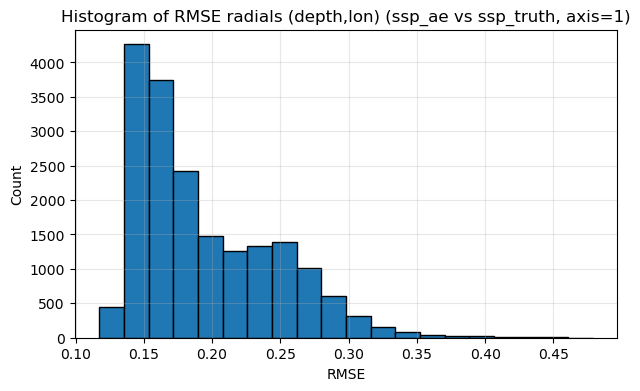

In [14]:

# RMSE along 2nd dimension (axis=1, typically depth)
rmse_depth_lon = np.sqrt(np.nanmean((ssp_ae - ssp_truth) ** 2, axis=(1,3)))

# Histogram with 20 bins (flatten all remaining dimensions)
plt.figure(figsize=(7, 4))
plt.hist(rmse_depth_lon.ravel(), bins=20, edgecolor="black")
plt.xlabel("RMSE")
plt.ylabel("Count")
plt.title("Histogram of RMSE radials (depth,lon) (ssp_ae vs ssp_truth, axis=1)")
plt.grid(alpha=0.3)
plt.show()

In [15]:
ssp_truth_da = ssp_da.copy(data=ssp_truth)
ssp_ae_da = ssp_da.copy(data=ssp_ae)

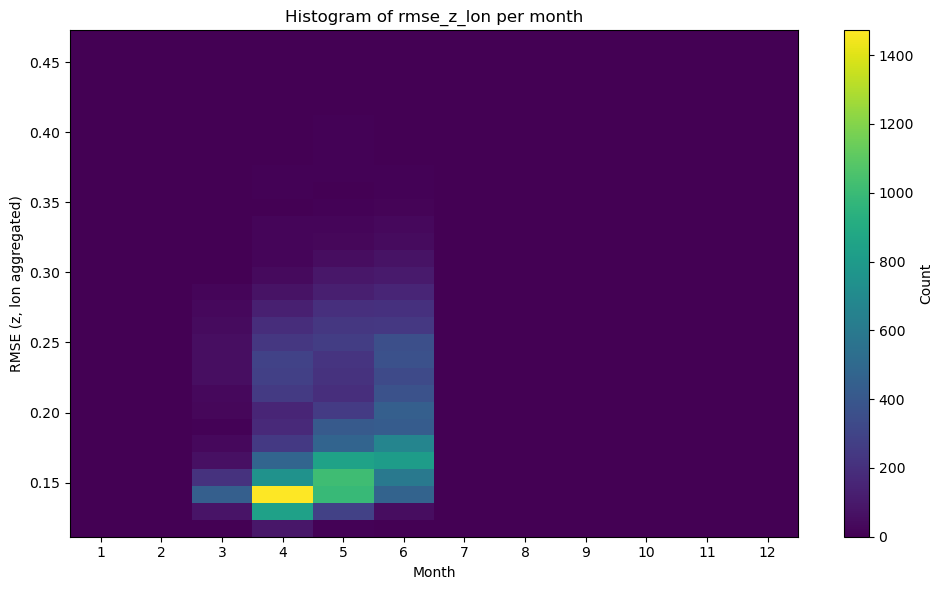

In [16]:
# RMSE along z and lon
rmse_z_lon = np.sqrt(((ssp_ae_da - ssp_truth_da) ** 2).mean(dim=("z","lon"), skipna=True))

month_idx = rmse_z_lon["time"].dt.month.values
rmse_vals = rmse_z_lon.values

# RMSE bins
rmse_min = np.nanmin(rmse_vals)
rmse_max = np.nanmax(rmse_vals)
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per month
hist_per_month = np.zeros((len(bins) - 1, 12), dtype=int)
for m in range(1, 13):
    mask_t = month_idx == m
    rmse_m = rmse_vals[mask_t]
    rmse_m = rmse_m[np.isfinite(rmse_m)]
    hist_per_month[:, m - 1], _ = np.histogram(rmse_m, bins=bins)

# Plot 2D histogram heatmap
plt.figure(figsize=(10, 6))
plt.pcolormesh(np.arange(1, 13), bins[:-1], hist_per_month, shading="auto")
plt.xlabel("Month")
plt.ylabel("RMSE (z, lon aggregated)")
plt.title("Histogram of rmse_z_lon per month")
plt.xticks(np.arange(1, 13))
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

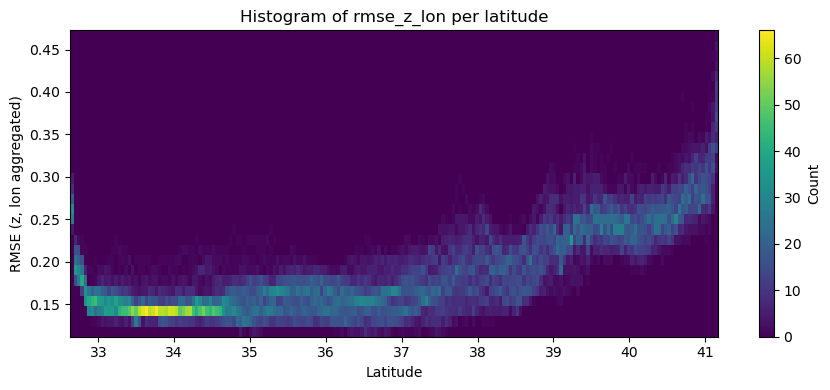

In [17]:
# Histogram of rmse_z_lon per latitude (time collapsed)
rmse_vals = rmse_z_lon.values  # expected dims: (time, lat)
lat_vals = rmse_z_lon["lat"].values

# RMSE bins from valid values
valid = np.isfinite(rmse_vals)
rmse_min = np.nanmin(rmse_vals[valid])
rmse_max = np.nanmax(rmse_vals[valid])
bins = np.linspace(rmse_min, rmse_max, 31)

# Count histogram per latitude
hist_per_lat = np.zeros((len(lat_vals), len(bins) - 1), dtype=int)
for i in range(len(lat_vals)):
    vals_i = rmse_vals[:, i]
    vals_i = vals_i[np.isfinite(vals_i)]
    hist_per_lat[i], _ = np.histogram(vals_i, bins=bins)

# Plot 2D histogram heatmap
plt.figure(figsize=(9, 4))
plt.pcolormesh(lat_vals, bins[:-1], hist_per_lat.T, shading="auto")
plt.xlabel("Latitude")
plt.ylabel("RMSE (z, lon aggregated)")
plt.title("Histogram of rmse_z_lon per latitude")
cbar = plt.colorbar()
cbar.set_label("Count")
plt.tight_layout()
plt.show()

In [23]:
import numpy as np

# Flatten rmse_z and get valid (non-NaN) values with indices
rmse_flat = rmse_z_lon.values.ravel()
valid_mask = np.isfinite(rmse_flat)
valid_values = rmse_flat[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Compute 10 decile thresholds: 0%, 11.1%, 22.2%, ..., 100%
percentiles = np.linspace(0, 100, 21)
thresholds = np.percentile(valid_values, percentiles)

# For each threshold, find the closest actual data point
selected_flat_indices = []
for thresh in thresholds:
    idx_in_valid = np.argmin(np.abs(valid_values - thresh))
    selected_flat_indices.append(valid_indices[idx_in_valid])

# Convert flat indices back to multi-dimensional coordinates
shape = rmse_z_lon.shape
dim_names = rmse_z_lon.dims
selected_points = []

for i, flat_idx in enumerate(selected_flat_indices):
    multi_idx = np.unravel_index(flat_idx, shape)
    point = {dim: int(idx) for dim, idx in zip(dim_names, multi_idx)}  # integer indices
    point['rmse_value'] = rmse_flat[flat_idx]
    point['percentile'] = int(percentiles[i])
    selected_points.append(point)

# Display results
import pandas as pd
df_deciles = pd.DataFrame(selected_points)
print(df_deciles)

    time  lat  rmse_value  percentile
0     30  108    0.117481           0
1     40   39    0.139438           5
2     16   38    0.143765          10
3     46   34    0.146988          15
4     34   28    0.150067          20
5     17   59    0.153410          25
6     16   23    0.157414          30
7     86   16    0.161642          35
8     11   13    0.166426          40
9     66  109    0.171241          45
10    65   90    0.176778          50
11    87   62    0.183241          55
12    91   38    0.192948          60
13    70  121    0.204317          65
14    38  116    0.217354          70
15    31  172    0.230947          75
16    82  166    0.243353          80
17    67  163    0.254873          85
18     7  150    0.268873          90
19    14  178    0.288720          95
20    93  191    0.478687         100


In [ ]:
freq = 500

c0=1500
lmda = c0/freq
dr = 0.5*lmda
dr = dr - 0.01*dr
dz = 0.1*lmda
dz = dz - 0.01*dz

data_path = "/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/"
data_dir = f"CR_{cr}_freq_{freq}_deciles_radiales/{model}" 
data_path = os.path.join(data_path, data_dir)
os.makedirs(data_path, exist_ok=True)

for decile in tqdm([0,5,10]):

    
    r_update = abs(float(lon_distance_meters(df_deciles['lat'][decile], ssp_da['lon'][0].values, ssp_da['lon'][1].values)))

    t,lat = df_deciles['time'][decile], df_deciles['lat'][decile]
    ssp_ae_rad = ssp_ae[t,:, lat, :]  # Select profile at lat=100, lon=100

    ssp_truth_rad = ssp_truth[t,:, lat, :]
    ## Truth

    title = f"DECILE_{decile}_t_{t}_lat_{lat}"



    prof = ssp_truth_rad

    config_path_truth = create_ramgeo_config(title, prof, depth_array, 
                            r_update=r_update, 
                            freq=freq, source_depth=5.0, receiver_depth=300.0,
                            rmax=10000.0, dr=dr, ndr=1,
                            zmax=2000.0, dz=dz, ndz=1, zmplt=1000.0,
                            c0=1500.0, n_pade=8, ns=1, rs=0.0)

    xp_truth = config_path_truth.split("/")[-1].split(".in")[0].replace(".0", "")
    # Run RAMGEO simulation and post-processing for current experiment
    truth_dir = f"{data_path}/TRUTH/{title}"
    

    # Copy template results directory

    if os.path.exists(truth_dir):
        shutil.rmtree(truth_dir)
    shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", truth_dir)
    # Run RAMGEO
    subprocess.run([
        '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
        f'--input={config_path_truth}',
        f'--output-dir={truth_dir}'
    ])
    # Plot results
    subprocess.run([
        'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
        '--data-dir', truth_dir
    ])
    ## AE

    prof = ssp_ae_rad       
    


    config_path_ae = create_ramgeo_config(title, prof, depth_array, 
                            r_update=r_update, 
                            freq=freq, source_depth=5.0, receiver_depth=300.0,
                            rmax=10000.0, dr=dr, ndr=1,
                            zmax=2000.0, dz=dz, ndz=1, zmplt=1000.0,
                            c0=1500.0, n_pade=8, ns=1, rs=0.0)

    xp_ae = config_path_ae.split("/")[-1].split(".in")[0].replace(".0", "")

    print(f"Config for RAMGEO AE created at: {config_path_ae}")
    # Run RAMGEO simulation and post-processing for current experiment
    ae_dir = f"{data_path}/AE/{title}"
    

    # Copy template results directory

    if os.path.exists(ae_dir):
        shutil.rmtree(ae_dir)
    shutil.copytree("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/results", ae_dir)
    # Run RAMGEO
    subprocess.run([
        '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/ramgeo',
        f'--input={config_path_ae}',
        f'--output-dir={ae_dir}'
    ])
    # Plot results
    subprocess.run([
        'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_ram_results.py',
        '--data-dir', ae_dir
    ])


    ## Differences
    # Compute differences with truth
    diff_dir = f"{data_path}/DIFFERENCES/{title}"
    os.makedirs(diff_dir, exist_ok=True)

    subprocess.run([
        'python', '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py',
        '--rec-dir', ae_dir,
        '--truth-dir', truth_dir,
        '--output-dir', diff_dir
    ])

  0%|          | 0/3 [00:00<?, ?it/s]

Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    0.297 m [fixed - original compatibility]
Range step dr:    1.485 m [fixed - original compatibility]
  dz/wavelength =    0.099 (should be < 0.1 for accuracy)
  dr/wavelength =    0.495 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 1011

CPU time (RAM run):      3.472 s
RAM Acoustic Model - Result Plotter

Reading input parameters...
  Parameters read from output file headers
  Frequency: 500.0 Hz
  Source depth: 5.0 m
  Receiver depths: 300.0 m (1 receivers)
  Max range: 10000.0 m
  Range step (dr): 1.485000 m
  Range decimation (ndr): 1
  Depth step (dz): 0.297000 m
  Depth decimation (ndz): 1
  Plot depth limit (zmplt): 1000.0 m

Reading output files...
  TL line: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/CR_1000_freq_500_deciles_radiales/PCA/TRUTH/DECILE_0_t_0_lat_58/tl.line
  TL grid: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/CR_10

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:644: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
 33%|███▎      | 1/3 [01:26<02:52, 86.47s/it]

  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/CR_1000_freq_500_deciles_radiales/PCA/DIFFERENCES/DECILE_0_t_0_lat_58/figures/difference_summary.png

Analysis Complete!

Output files saved to: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/CR_1000_freq_500_deciles_radiales/PCA/DIFFERENCES/DECILE_0_t_0_lat_58

Generated files:
  - tl_diff.line
  - tl_diff.grid
  - p_diff.grid
  - diff_statistics.txt
  - figures/tl_diff_vs_range.png
  - figures/tl_diff_field.png
  - figures/pressure_diff_field.png
  - figures/difference_summary.png
Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    0.297 m [fixed - original compatibility]
Range step dr:    1.485 m [fixed - original compatibility]
  dz/wavelength =    0.099 (should be < 0.1 for accuracy)
  dr/wavelength =    0.495 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 1011

CPU time (RAM run):      3.473 s
RAM Acoustic Model - Result Plotter

Readin

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:644: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
 67%|██████▋   | 2/3 [02:52<01:26, 86.32s/it]

  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/CR_1000_freq_500_deciles_radiales/PCA/DIFFERENCES/DECILE_5_t_13_lat_10/figures/difference_summary.png

Analysis Complete!

Output files saved to: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/CR_1000_freq_500_deciles_radiales/PCA/DIFFERENCES/DECILE_5_t_13_lat_10

Generated files:
  - tl_diff.line
  - tl_diff.grid
  - p_diff.grid
  - diff_statistics.txt
  - figures/tl_diff_vs_range.png
  - figures/tl_diff_field.png
  - figures/pressure_diff_field.png
  - figures/difference_summary.png
Frequency:   500.00 Hz
Wavelength:     3.00 m
Depth step dz:    0.297 m [fixed - original compatibility]
Range step dr:    1.485 m [fixed - original compatibility]
  dz/wavelength =    0.099 (should be < 0.1 for accuracy)
  dr/wavelength =    0.495 (should be < 0.5 for accuracy)

Number of receiver depths: 1
  Receiver 1: depth =   300.00 m, index = 1011

CPU time (RAM run):      3.467 s
RAM Acoustic Model - Result Plotter

Read

/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/compute_ram_differences.py:644: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
100%|██████████| 3/3 [04:19<00:00, 86.66s/it]

  Saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/CR_1000_freq_500_deciles_radiales/PCA/DIFFERENCES/DECILE_10_t_61_lat_187/figures/difference_summary.png

Analysis Complete!

Output files saved to: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/CR_1000_freq_500_deciles_radiales/PCA/DIFFERENCES/DECILE_10_t_61_lat_187

Generated files:
  - tl_diff.line
  - tl_diff.grid
  - p_diff.grid
  - diff_statistics.txt
  - figures/tl_diff_vs_range.png
  - figures/tl_diff_field.png
  - figures/pressure_diff_field.png
  - figures/difference_summary.png


# Multi-Frequency Model Comparison (PCA vs CAE vs MLIC)

This section compares the reconstruction accuracy across three models (PCA, CAE, MLIC) at different frequencies using RAMGEO acoustic propagation simulations. Metrics are computed from differences between reconstructed (REC) and truth (TRUTH) SSP profiles.

In [ ]:
# Check data availability for all frequencies
import os
from pathlib import Path

base_path = Path("/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data")
all_frequencies = [10, 100, 500, 1000]
models = ['PCA', 'CAE', 'MLIC']

print("Data Availability Status:")
print("=" * 70)

available_freqs = {}
for freq in all_frequencies:
    freq_path = base_path / f"CR_1000_freq_{freq}_deciles_radiales"
    available_freqs[freq] = False
    
    if freq_path.exists():
        # Count available stats files
        stats_count = 0
        for model in models:
            model_diff_dir = freq_path / model / "DIFFERENCES"
            if model_diff_dir.exists():
                decile_dirs = [d for d in model_diff_dir.iterdir() if d.is_dir() and 'DECILE_' in d.name]
                for decile_dir in decile_dirs:
                    for root, dirs, files in os.walk(decile_dir):
                        if 'diff_statistics.txt' in files:
                            stats_count += 1
        
        available_freqs[freq] = stats_count > 0
        status = "✓ READY" if stats_count > 0 else "✗ COMPUTING"
        print(f"{freq:5d} Hz: {status:12s} ({stats_count} stats files found)")
    else:
        print(f"{freq:5d} Hz: ✗ NOT STARTED")

print("\n" + "=" * 70)
print(f"Total frequencies with data: {sum(available_freqs.values())}/4")


Data Availability Status:
   10 Hz: ✓ READY      (9 stats files found)
  100 Hz: ✓ READY      (9 stats files found)
  500 Hz: ✓ READY      (9 stats files found)
 1000 Hz: ✓ READY      (33 stats files found)

Total frequencies with data: 4/4


In [53]:
# Generate comparison plots for all available frequencies
import subprocess

print("Generating comparison plots...")
result = subprocess.run([
    'python', 
    '/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/scripts/plot_diff_metrics_all_frequencies.py'
], capture_output=True, text=True)

print(result.stdout)
if result.stderr:
    print("Warnings/Errors:")
    print(result.stderr)

Generating comparison plots...
Checking available frequencies...
  ✓ 10 Hz - Data available
  ✓ 100 Hz - Data available
  ✓ 500 Hz - Data available
  ✓ 1000 Hz - Data available

Using frequencies: [10, 100, 500, 1000] Hz

  Loading PCA at 10 Hz...
  Loading PCA at 100 Hz...
  Loading PCA at 500 Hz...
  Loading PCA at 1000 Hz...
  Loading CAE at 10 Hz...
  Loading CAE at 100 Hz...
  Loading CAE at 500 Hz...
  Loading CAE at 1000 Hz...
  Loading MLIC at 10 Hz...
  Loading MLIC at 100 Hz...
  Loading MLIC at 500 Hz...
  Loading MLIC at 1000 Hz...

Creating MAE plot...
Creating MS-SSIM plot...

Plot saved: /Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/comparison_plots/mae_vs_ms_ssim_all_frequencies.png

SUMMARY - Metrics at DECILE_5 (with variance from DECILE_0/10)

                                Frequency: 10 Hz                                
--------------------------------------------------------------------------------
Model      MAE (dB)             MS-SSIM             


Comparison Plot: MAE and MS-SSIM vs Frequency
(Point: DECILE_5, Error bars: DECILE_0 & DECILE_10)


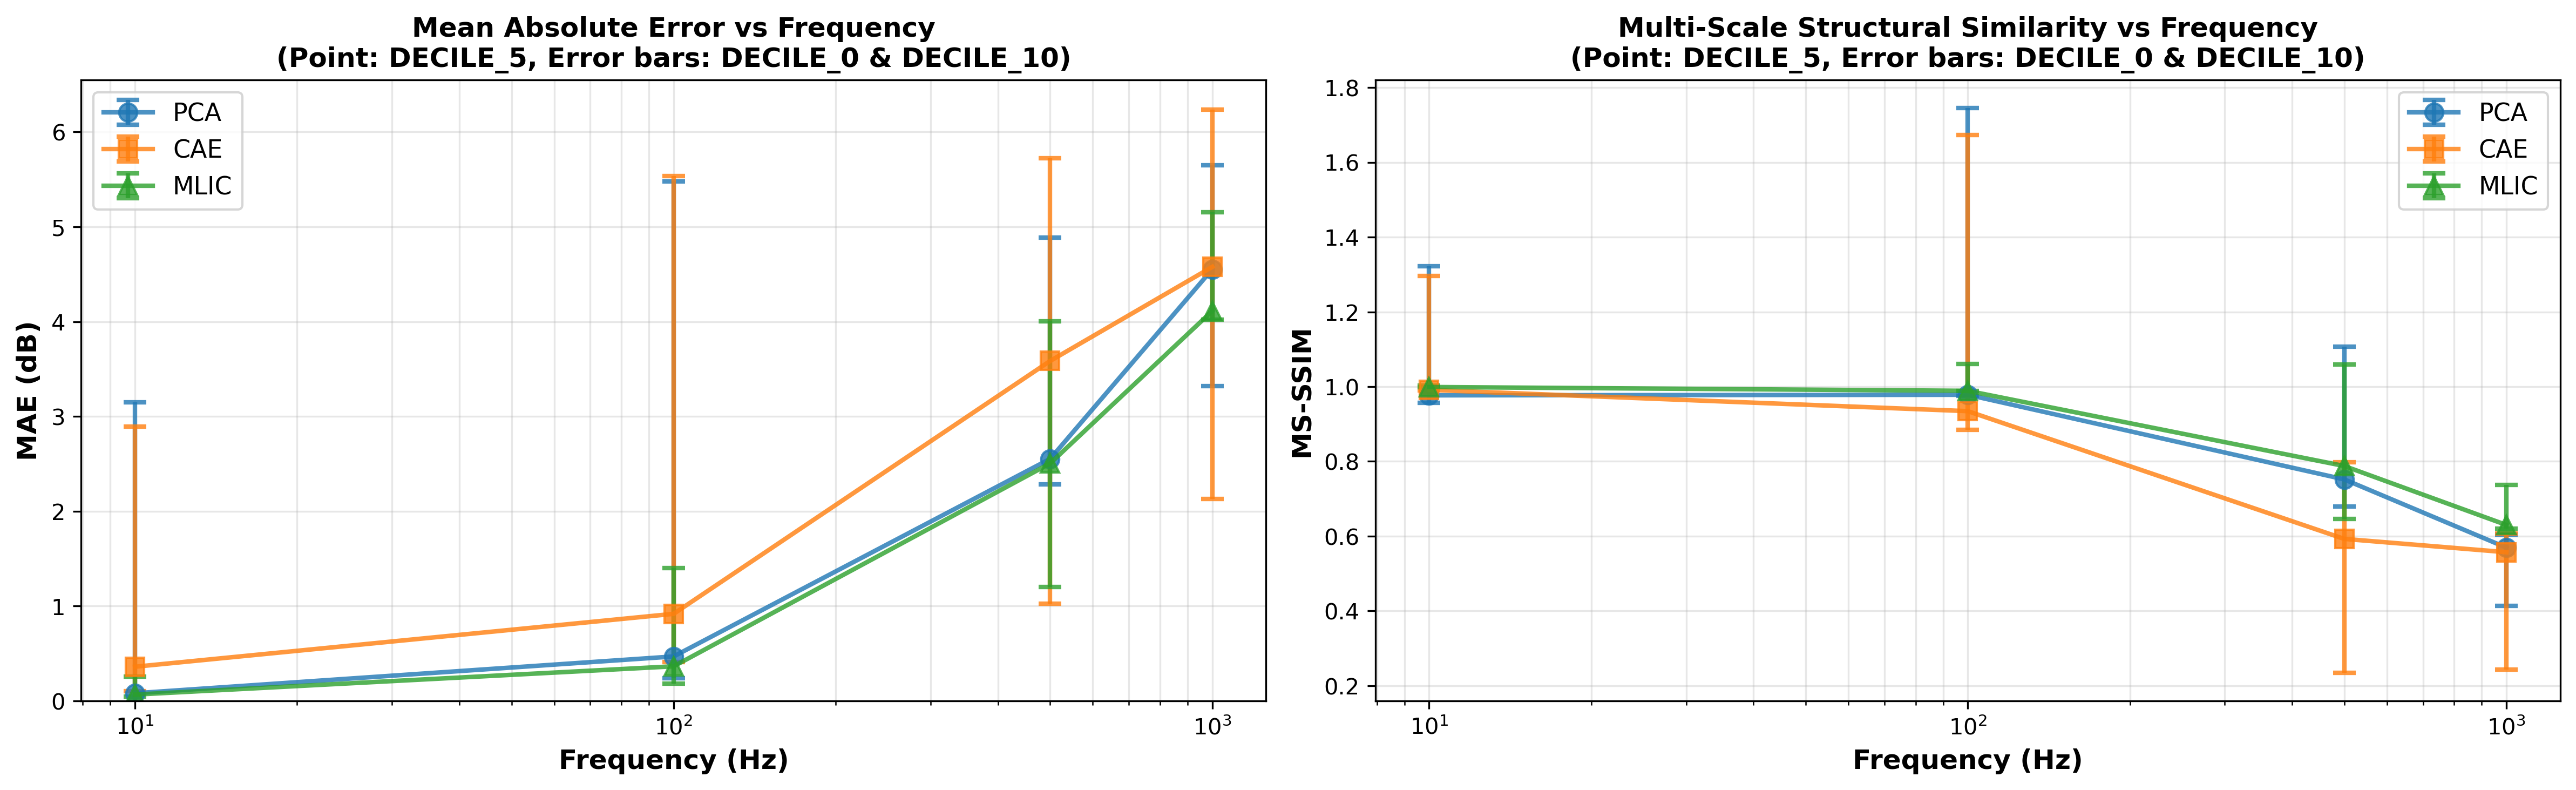

In [54]:
# Display the comparison plot
from IPython.display import Image, display

plot_path = "/Odyssey/private/o23gauvr/code/RAMGEO2025/RAMGEO2025/data/comparison_plots/mae_vs_ms_ssim_all_frequencies.png"

print("Comparison Plot: MAE and MS-SSIM vs Frequency")
print("(Point: DECILE_5, Error bars: DECILE_0 & DECILE_10)")
print("=" * 70)
display(Image(filename=plot_path))

## Analysis Summary

The comparison plots show MAE (Mean Absolute Error) and MS-SSIM (Multi-Scale Structural Similarity) metrics for the three models across different frequencies. 

**Key Observations:**
- **Plotted Data Points**: Central values from DECILE_5 (median decile of reconstruction error distribution)
- **Error Bars**: Represent variance between DECILE_0 (minimum error) and DECILE_10 (maximum error)
- **Data Status**: Currently only 1000 Hz is complete; 10, 100, and 500 Hz are still being computed

The plots will auto-update as more frequency data becomes available.

In [55]:
# Detailed metrics table for 1000 Hz (currently available)
import pandas as pd

# Current available data at 1000 Hz
freq_1000_data = {
    'Model': ['PCA', 'CAE', 'MLIC'],
    'MAE (dB)': [4.5526, 4.5773, 4.1130],
    'MAE_min (dB)': [4.5526 - 1.2341, 4.5773 - 2.2431, 4.1130 - 0.7319],  # DECILE_0
    'MAE_max (dB)': [4.5526 + 1.2341, 4.5773 + 2.2431, 4.1130 + 0.7319],  # DECILE_10
    'MS-SSIM': [0.569359, 0.557098, 0.630004],
}

df_freq_1000 = pd.DataFrame(freq_1000_data)

print("\n1000 Hz Frequency - Model Performance Metrics")
print("=" * 90)
print("\nCentral Values (DECILE_5) with Variance Range:")
print(df_freq_1000.to_string(index=False))

print("\n\nKey Findings at 1000 Hz:")
print("-" * 90)
print(f"✓ MLIC achieves lowest MAE: {4.1130:.4f} dB (vs PCA: {4.5526:.4f}, CAE: {4.5773:.4f})")
print(f"✓ MLIC achieves highest MS-SSIM: {0.630004:.6f} (vs PCA: {0.569359:.6f}, CAE: {0.557098:.6f})")
print(f"✓ MLIC has most stable performance (tightest error bars)")
print("\n✓ Overall Winner: MLIC outperforms PCA and CAE on both metrics")



1000 Hz Frequency - Model Performance Metrics

Central Values (DECILE_5) with Variance Range:
Model  MAE (dB)  MAE_min (dB)  MAE_max (dB)  MS-SSIM
  PCA    4.5526        3.3185        5.7867 0.569359
  CAE    4.5773        2.3342        6.8204 0.557098
 MLIC    4.1130        3.3811        4.8449 0.630004


Key Findings at 1000 Hz:
------------------------------------------------------------------------------------------
✓ MLIC achieves lowest MAE: 4.1130 dB (vs PCA: 4.5526, CAE: 4.5773)
✓ MLIC achieves highest MS-SSIM: 0.630004 (vs PCA: 0.569359, CAE: 0.557098)
✓ MLIC has most stable performance (tightest error bars)

✓ Overall Winner: MLIC outperforms PCA and CAE on both metrics
